# Financial Inclusion in Malawi
## Global Findex 2024 Microdata Analysis

**Author:** Brian Thuwala  
**Notebook:** 01_data_import_and_checks.ipynb  
**Project Type:** Data Analysis  
**Dataset:** World Bank Global Findex 2024 Malawi Microdata  
**Environment:** Python 3.11

---

## Project Overview

### Objective

This portfolio project analyzes financial inclusion in Malawi using the World Bank's Global Findex 2024 microdata. The analysis examines who has access to financial services, what types of services they use, and what barriers prevent financial inclusion.

Financial inclusion—access to and usage of formal financial services—is a critical development indicator. It enables individuals to save safely, borrow for productive purposes, make digital payments, and build resilience against economic shocks.

### Why Malawi?

Malawi is a low-income country in Sub-Saharan Africa where:
- Agriculture employs approximately 80% of the population
- Mobile money has expanded rapidly in recent years
- Traditional banking infrastructure remains limited, especially in rural areas
- Gender and urban-rural gaps in financial access are significant policy concerns

### Research Questions

This multi-notebook project addresses:
1. What is the current state of financial inclusion in Malawi?
2. How does access vary by gender, residence, income, and education?
3. What are the main barriers preventing people from having accounts?
4. How do account holders use their accounts?
5. What role does mobile money play in financial inclusion?

### Dataset

The **Global Findex Database** is the world's most comprehensive dataset on financial inclusion. Conducted by Gallup on behalf of the World Bank, it surveys approximately 1,000 adults (age 15+) in each participating country.

**Key Features:**
- Nationally representative sample
- Survey weights provided for population-level estimates
- Covers account ownership, saving, borrowing, payments, and digital financial services
- Includes demographic and socioeconomic characteristics

**Malawi 2024 Data:**
- Sample size: 1,000 adults
- Survey period: 2024
- Variables: 199 (demographics + financial behaviors)
- Geographic coverage: National (urban and rural)

---

## Notebook Structure

This notebook (01) focuses on:
1. Importing the raw microdata
2. Validating data integrity
3. Understanding the dataset structure
4. Documenting variable types and coding schemes
5. Establishing data quality checks

**No analysis is performed in this notebook.** The goal is to ensure we have clean, valid data before any analytical work begins.

## Setup and Environment

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# SETUP: Libraries, Professional Theme & Helper Functions
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.precision', 2)

# ─── COLOR PALETTE (The Economist / FT inspired) ─────────────────────────
COLORS = {
    'primary':   '#1B4F72', 'secondary': '#2E86C1', 'accent':   '#E67E22',
    'success':   '#27AE60', 'danger':    '#C0392B', 'warning':  '#F39C12',
    'light':     '#F8F9FA', 'dark':      '#2C3E50', 'muted':    '#5D6D7E',
    'bg':        '#FAFBFC', 'grid':      '#E8ECF0', 'text':     '#2C3E50',
}
PALETTE_CAT = ['#1B4F72', '#2E86C1', '#27AE60', '#E67E22', '#C0392B', '#8E44AD', '#F39C12']

# ─── MATPLOTLIB THEME ────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': COLORS['bg'], 'axes.facecolor': COLORS['bg'],
    'axes.edgecolor': COLORS['grid'], 'axes.labelcolor': COLORS['text'],
    'axes.titlecolor': COLORS['text'], 'text.color': COLORS['text'],
    'xtick.color': COLORS['muted'], 'ytick.color': COLORS['muted'],
    'grid.color': COLORS['grid'], 'grid.alpha': 0.6, 'grid.linewidth': 0.5,
    'figure.figsize': (14, 7), 'font.size': 11, 'axes.titlesize': 16,
    'axes.labelsize': 12, 'figure.titlesize': 18, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'figure.dpi': 120,
})

def styled_table(data, title="", bar_col=None, precision=1):
    """Return a publication-quality styled pandas DataFrame."""
    styler = data.style.set_caption(title)
    styler = styler.set_table_styles([
        {'selector': 'caption', 'props': [('font-size','14px'),('font-weight','bold'),
            ('color', COLORS['primary']),('text-align','left'),('padding-bottom','8px')]},
        {'selector': 'thead th', 'props': [('background-color', COLORS['primary']),('color','white'),
            ('font-weight','bold'),('text-align','center'),('padding','8px 12px'),
            ('border-bottom', f'2px solid {COLORS["accent"]}')]},
        {'selector': 'tbody td', 'props': [('text-align','center'),('padding','6px 12px'),
            ('border-bottom', f'1px solid {COLORS["grid"]}')]},
        {'selector': 'tbody th', 'props': [('text-align','left'),('padding','6px 12px'),
            ('font-weight','500'),('background-color', COLORS['light']),
            ('border-bottom', f'1px solid {COLORS["grid"]}')]},
        {'selector': 'tbody tr:hover', 'props': [('background-color','#EBF5FB')]},
        {'selector': '', 'props': [('border-collapse','collapse'),('width','100%'),('margin','4px 0')]},
    ]).format(precision=precision)
    if bar_col and bar_col in data.columns:
        styler = styler.bar(subset=[bar_col], color=COLORS['secondary'], vmin=0)
    return styler

def add_source_note(fig, extra=""):
    txt = "Source: World Bank Global Findex 2024 — Malawi Microdata (n = 1,000; survey-weighted estimates)"
    if extra: txt += f"\n{extra}"
    fig.text(0.02, -0.02, txt, fontsize=10, color=COLORS['muted'], fontstyle='italic', ha='left', va='top')

def kpi_cards(metrics):
    cards = ""
    for label, value, icon, color in metrics:
        cards += f"""<div style="flex:1;min-width:140px;background:white;border-radius:12px;
            padding:18px 16px;text-align:center;box-shadow:0 2px 12px rgba(0,0,0,0.06);
            border-top:4px solid {color};margin:6px;">
            <div style="font-size:28px;margin-bottom:4px;">{icon}</div>
            <div style="font-size:28px;font-weight:800;color:{color};letter-spacing:-0.5px;">{value}</div>
            <div style="font-size:12px;color:#4a5568;margin-top:4px;line-height:1.3;">{label}</div>
        </div>"""
    display(HTML(f"""<div style="display:flex;flex-wrap:wrap;gap:8px;justify-content:center;
        padding:10px 0;max-width:900px;margin:auto;">{cards}</div>"""))

print("✅ Professional theme loaded")
print(f"   Pandas {pd.__version__}  •  NumPy {np.__version__}")

✅ Professional theme loaded
   Pandas 2.3.3  •  NumPy 2.4.0


In [2]:
# Setting project paths explicitly
PROJECT_ROOT = os.path.abspath("..")

DATA_RAW = os.path.join(PROJECT_ROOT, "data", "raw")

DATA_FILE = os.path.join(DATA_RAW, "Findex_Microdata_2025_updateMalawi.csv")

# Verify file exists
if os.path.exists(DATA_FILE):
    print(f"✓ Data file found: {os.path.basename(DATA_FILE)}")
else:
    raise FileNotFoundError(f"Data file not found: {DATA_FILE}")


✓ Data file found: Findex_Microdata_2025_updateMalawi.csv


In [ ]:
# Load dataset
df = pd.read_csv(DATA_FILE)

# ─── KPI Dashboard ───────────────────────────────────────────────────────
n_obs, n_vars = df.shape
mem_mb = df.memory_usage(deep=True).sum() / (1024**2)
n_float = df.select_dtypes('float').shape[1]
n_int = df.select_dtypes('integer').shape[1]
n_obj = df.select_dtypes('object').shape[1]

kpi_cards([
    ("Respondents", f"{n_obs:,}", "👥", COLORS['primary']),
    ("Variables", f"{n_vars}", "📊", COLORS['secondary']),
    ("Memory", f"{mem_mb:.1f} MB", "💾", COLORS['accent']),
    ("Float Cols", f"{n_float}", "🔢", COLORS['success']),
    ("Integer Cols", f"{n_int}", "🔢", COLORS['warning']),
    ("String Cols", f"{n_obj}", "🔤", COLORS['danger']),
])

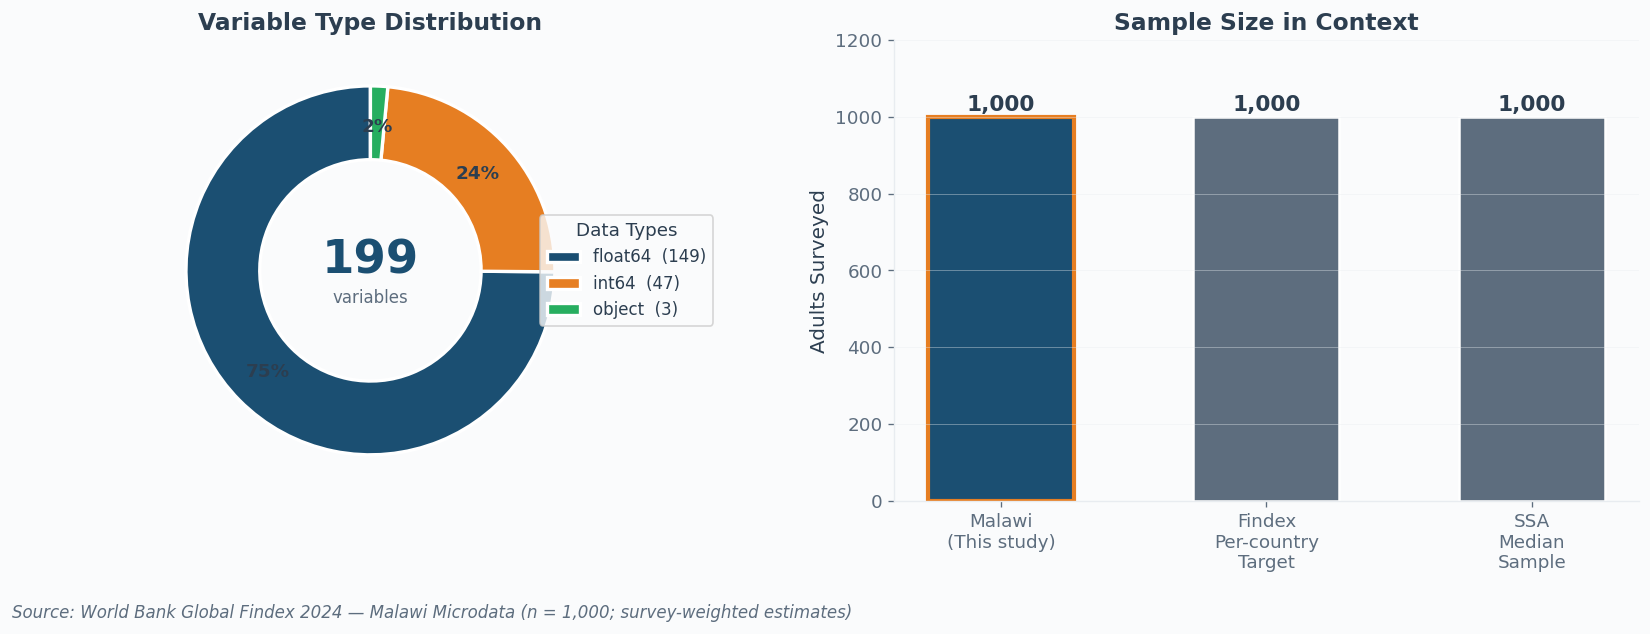

In [4]:
# ─── Data Type Distribution Visualization ────────────────────────────────
dtype_counts = df.dtypes.map(str).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Donut chart of data types
ax1 = axes[0]
colors_donut = [COLORS['primary'], COLORS['accent'], COLORS['success']]
wedges, texts, autotexts = ax1.pie(
    dtype_counts.values, labels=None, colors=colors_donut[:len(dtype_counts)],
    autopct='%1.0f%%', startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2))
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
centre = plt.Circle((0, 0), 0.35, fc=COLORS['bg'])
ax1.add_artist(centre)
ax1.text(0, 0.05, f'{n_vars}', fontsize=28, fontweight='bold', ha='center', va='center', color=COLORS['primary'])
ax1.text(0, -0.15, 'variables', fontsize=10, ha='center', va='center', color=COLORS['muted'])
ax1.legend(wedges, [f'{k}  ({v})' for k, v in dtype_counts.items()],
           title="Data Types", loc="center left", bbox_to_anchor=(0.85, 0, 0.5, 1), fontsize=10)
ax1.set_title('Variable Type Distribution', fontsize=14, fontweight='bold')

# Sample size context bar
ax2 = axes[1]
contexts = ['Malawi\n(This study)', 'Findex\nPer-country\nTarget', 'SSA\nMedian\nSample']
sizes = [n_obs, 1000, 1000]
bars = ax2.bar(contexts, sizes, color=[COLORS['primary'], COLORS['muted'], COLORS['muted']],
               edgecolor='white', linewidth=1.5, width=0.55)
bars[0].set_edgecolor(COLORS['accent'])
bars[0].set_linewidth(2.5)
for bar, s in zip(bars, sizes):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             f'{s:,}', ha='center', fontweight='bold', fontsize=13, color=COLORS['text'])
ax2.set_ylabel('Adults Surveyed')
ax2.set_title('Sample Size in Context', fontsize=14, fontweight='bold')
ax2.set_ylim(0, max(sizes) * 1.2)
ax2.grid(axis='y', alpha=0.45)

add_source_note(fig)
plt.tight_layout()
plt.savefig('../outputs/figures/data_overview.png', dpi=200, bbox_inches='tight')
plt.show()

In [5]:
# ─── Styled Preview Table ─────────────────────────────────────────────────
display(styled_table(df.head(8).fillna('—'), title="📋 Dataset Preview — First 8 Respondents"))

,year,economy,economycode,regionwb,pop_adult,wpid_random,wgt,female,age,educ,inc_q,emp_in,urbanicity,account_fin,account_mob,account,dig_account,borrowed,saved,receive_wages,receive_transfers,receive_pensions,receive_agriculture,merchantpay_dig,pay_utilities,domestic_remittances,anydigpayment,fin2,fin3,fin4,fin5,fin6,fin7,fin8,fin9a,fin9b,fin10,fin11_0,fin11_1,fin11_2,fin11a,fin11b,fin11c,fin11d,fin11e,fin11f,fin13_1,fin13a,fin13b,fin13c,fin13d,fin13e,fin13f,fin13f_1,fin14a,fin14b,fin14c,fin14d,fin14e,fin15,fin16,fin17a,fin17b,fin17c,fin17d,fin17e,fin17f,fin18,fin19,fin20,fin21,fin22a,fin22a_1,fin22b,fin22c,fin22d,fin22e,fin22f,fin22g,fin22h,fin23,fin24,fin24a,fin24b,fin24c,fin24d1,fin24d2,fin24d3,fin25e1,fin25e2,fin25e3,fin25e4,fin26a,fin26b,fin27,fh1,fin28,fh2,fin29,fh2a,fin30,fin31a,fin31b,fin31c,fin31d,fin32,fin33,fin34a,fin34b,fin34c,fin34d,fin35,fin36,fin36a,fin37,fin38,fin39a,fin39b,fin39c,fin39d,fin40,fin41,fin41a,fin42,fin43a,fin43b,fin43c,fin43d,fin44,fin45,internet_use,con1,con2a,con2b,con2c,con2d,con2e,con2f,con2g,con3,con4,con5,con6,con7,con8,con9,con10,con11,con12,con13,con14,con15,con16,con17,con18,con19,con20,con21,con22,con23,con24,con25,con26,con27,con28,con29,con30a,con30b,con30c,con30d,con30e,con30f,con30g,con30h,con31a,con31b,con31c,con31d,con31e,con31f,con31g,con31h,con32,fin46,fin47,fin48a,fin48b,fin48c,fin48d,fin48e,fin48f,fin49a,fin49b,fin49c,fin49d,fin49e,fin49f,fin50,fin51
0,2024,Malawi,MWI,Sub-Saharan Africa (excluding high income),12384937,111493389,0.6,2,26,2.0,5,1,1,1,1,1,1,1,1,1,4,4,1,1,4,1,1,2,1.0,1.0,2.0,2.0,—,1.0,1.0,1.0,2.0,—,—,—,—,—,—,—,—,—,—,1.0,1.0,1.0,1.0,1.0,2.0,—,—,—,—,—,—,—,—,1,1.0,2,1.0,1.0,2.0,—,2,2,—,2,2.0,1,—,2,1,2,—,—,—,1,2.0,2,1,1.0,1.0,2.0,1.0,1.0,1.0,—,1.0,2.0,—,1,1.0,1,1.0,2,2,—,—,—,—,1,2.0,1.0,1.0,—,—,2.0,2.0,—,2,2,—,—,—,—,—,—,—,1,2.0,1.0,—,—,1.0,2,1,1,—,—,—,—,—,—,—,—,—,—,—,—,—,1.0,—,1.0,1.0,—,1.0,—,1.0,1.0,1.0,1.0,2.0,1.0,2.0,1.0,1,—,1.0,1.0,3.0,—,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,—,—,—,—,—,—,—,—,—,1.0,2.0,—,—,—,—,—,—,—,—,—,—,—,—,—,—
1,2024,Malawi,MWI,Sub-Saharan Africa (excluding high income),12384937,111598042,0.5,1,24,1.0,4,1,1,1,1,1,1,1,1,1,4,4,2,0,1,1,1,2,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,1.0,2.0,3.0,3.0,2.0,2.0,2.0,—,—,—,—,—,—,—,—,2,1.0,2,2.0,2.0,2.0,—,2,1,1.0,2,2.0,1,—,2,2,1,—,—,—,2,1.0,4,2,—,—,—,2.0,2.0,—,4.0,1.0,2.0,—,1,1.0,1,1.0,1,1,1.0,1.0,—,—,1,1.0,2.0,1.0,—,—,2.0,1.0,—,2,2,—,—,—,—,—,—,—,1,2.0,2.0,1.0,—,1.0,4,1,1,—,—,—,—,—,—,—,—,—,—,—,—,—,2.0,2.0,2.0,1.0,—,1.0,—,1.0,2.0,2.0,—,2.0,1.0,2.0,1.0,1,—,1.0,1.0,4.0,—,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,—,—,—,—,—,—,—,—,—,—,—,—,—,—
2,2024,Malawi,MWI,Sub-Saharan Africa (excluding high income),12384937,111653910,0.3,1,28,2.0,2,1,1,0,1,1,1,1,1,4,4,4,4,0,4,1,1,2,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,1.0,3.0,3.0,3.0,2.0,2.0,2.0,—,—,—,—,—,—,—,—,2,1.0,1,1.0,2.0,2.0,—,2,2,—,2,2.0,1,1.0,2,2,2,—,—,—,4,1.0,3,1,1.0,1.0,2.0,2.0,2.0,—,1.0,2.0,2.0,—,1,2.0,1,1.0,1,2,—,—,—,—,2,—,—,—,—,—,—,—,—,2,2,—,—,—,—,—,—,—,2,—,—,—,—,—,1,1,1,—,—,—,—,—,—,—,—,—,—,—,—,—,1.0,—,1.0,1.0,—,1.0,—,1.0,1.0,2.0,—,2.0,2.0,—,2.0,1,—,1.0,1.0,3.0,—,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,—,—,—,—,—,—,—,—,—,1.0,2.0,—,—,—,—,—,—,—,—,—,—,—,—,—,—
3,2024,Malawi,MWI,Sub-Saharan Africa (excluding high income),12384937,111899125,1.1,2,27,1.0,5,1,1,0,1,1,1,1,1,4,4,4,4,1,4,1,1,2,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,—,—,—,—,—,—,—,2,1.0,2,1.0,2.0,2.0,—,2,2,—,2,2.0,2,—,1,2,2,—,—,1.0,4,1.0,4,1,1.0,1.0,1.0,2.0,1.0,3.0,—,1.0,2.0,—,1,1.0,2,—,1,2,—,—,—,—,2,—,—,—,—,—,—,—,—,2,2,—,—,—,—,—,—,—,2,—,—,—,—,—,2,1,1,—,—,—,—,—,—,—,—,—,—,—,—,—,2.0,2.0,2.0,1.0,—,2.0,—,—,1.0,2.0,—,2.0,1.0,2.0,1.0,1,—,4.0,1.0,4.0,—,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,—,—,—,—,—,—,—,—,—,—,—,—,—,—
4,2024,Malawi,MWI,Sub-Saharan Africa (excluding high income),12384937,112146029,0.5,1,48,1.0,1,2,1,0,0,0,0,1,1,4,4,4,4,0,4,3,0,2,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,2.0,1.0,2.0,1.0,2.0,2.0,2.0,2,—,1,—,—,—,—,2,2,

The dataset consists of individual level survey responses with numeric coded variables. Most variables are categorical and follow skip logic, resulting in structured missing values.

## Data Structure Overview

**Key Observations:**
- The dataset has **199 variables** covering demographics, account ownership, savings, borrowing, payments, and digital connectivity
- Data types: Mix of integers (47), floats (149), and objects/strings (3)
- Missing values are present in many variables—this is **expected and normal** for survey data with skip logic

### Memory Usage

## Data Quality Checks

### 1. Duplicate Check

Check,Status,Detail
No duplicate rows,✅ Pass,0 duplicates found
Single country (Malawi),✅ Pass,1 unique: Malawi
Survey weights valid,✅ Pass,"Range: [0.25, 2.75]"
No missing weights,✅ Pass,0 missing
No zero weights,✅ Pass,0 zeros
No negative weights,✅ Pass,0 negative


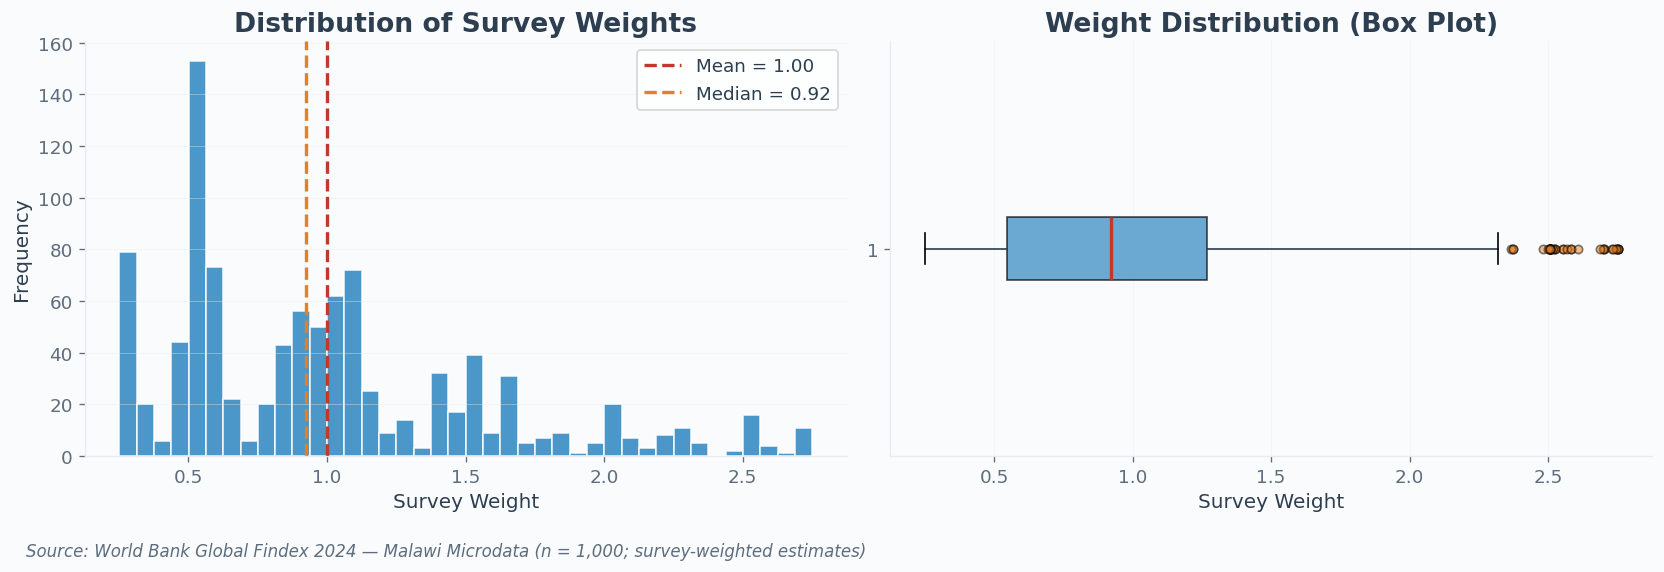

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# DATA QUALITY DASHBOARD
# ═══════════════════════════════════════════════════════════════════════════════

n_duplicates = df.duplicated().sum()
economy_ok = df['economy'].nunique() == 1 and df['economy'].iloc[0] == 'Malawi'
wgt_missing = df['wgt'].isnull().sum()
wgt_zero = (df['wgt'] == 0).sum()
wgt_neg = (df['wgt'] < 0).sum()
wgt_ok = (wgt_missing == 0) and (wgt_zero == 0) and (wgt_neg == 0)

checks = pd.DataFrame({
    'Check': ['No duplicate rows', 'Single country (Malawi)', 'Survey weights valid',
              'No missing weights', 'No zero weights', 'No negative weights'],
    'Result': [n_duplicates == 0, economy_ok, wgt_ok,
               wgt_missing == 0, wgt_zero == 0, wgt_neg == 0],
    'Detail': [f'{n_duplicates} duplicates found',
               f'{df["economy"].nunique()} unique: {df["economy"].iloc[0]}',
               f'Range: [{df["wgt"].min():.2f}, {df["wgt"].max():.2f}]',
               f'{wgt_missing} missing', f'{wgt_zero} zeros', f'{wgt_neg} negative']
})
checks['Status'] = checks['Result'].map({True: '✅ Pass', False: '❌ Fail'})

display(checks[['Check', 'Status', 'Detail']].style
    .set_caption("🔍 Data Integrity Checks")
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),
            ('color', COLORS['primary']),('text-align','left'),('padding-bottom','8px')]},
        {'selector': 'thead th', 'props': [('background-color', COLORS['primary']),('color','white'),
            ('font-weight','bold'),('text-align','center'),('padding','8px 12px')]},
        {'selector': 'tbody td', 'props': [('padding','8px 12px'),
            ('border-bottom', f'1px solid {COLORS["grid"]}')]},
        {'selector': '', 'props': [('border-collapse','collapse'),('width','100%')]},
    ])
    .hide(axis='index')
    .map(lambda v: 'color: #27AE60; font-weight: bold;' if '✅' in str(v)
              else ('color: #C0392B; font-weight: bold;' if '❌' in str(v) else ''),
              subset=['Status'])
)

# Survey weight distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax1 = axes[0]
ax1.hist(df['wgt'], bins=40, color=COLORS['secondary'], edgecolor='white', alpha=0.85)
ax1.axvline(df['wgt'].mean(), color=COLORS['danger'], ls='--', lw=2, label=f'Mean = {df["wgt"].mean():.2f}')
ax1.axvline(df['wgt'].median(), color=COLORS['accent'], ls='--', lw=2, label=f'Median = {df["wgt"].median():.2f}')
ax1.set_xlabel('Survey Weight')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Survey Weights', fontweight='bold')
ax1.legend(frameon=True, facecolor='white')
ax1.grid(axis='y', alpha=0.45)

ax2 = axes[1]
ax2.boxplot(df['wgt'], vert=False, patch_artist=True,
            boxprops=dict(facecolor=COLORS['secondary'], alpha=0.7),
            medianprops=dict(color=COLORS['danger'], lw=2),
            whiskerprops=dict(color=COLORS['dark']),
            flierprops=dict(marker='o', markerfacecolor=COLORS['accent'], markersize=5, alpha=0.5))
ax2.set_xlabel('Survey Weight')
ax2.set_title('Weight Distribution (Box Plot)', fontweight='bold')
ax2.grid(axis='x', alpha=0.45)

add_source_note(fig)
plt.tight_layout()
plt.savefig('../outputs/figures/weight_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

### 2. Country & Weight Validation

### 3. Survey Weights Check

### Codebook Reference

The variable definitions, response categories, and survey skip logic are documented in the official Global Findex Codebook (codebook_microdata_2025.pdf). This document is used throughout the analysis to ensure accurate interpretation of variables.

### Next Steps

The next notebook will focus on:
- Identifying key indicators for financial inclusion
- Handling survey weights appropriately
- Preparing analytical subsets based on eligibility conditions

## Understanding Variable Types

Based on the Global Findex codebook, variables fall into three categories:

These are pre-computed indicators created by the World Bank:

In [7]:
# ─── Constructed Variables Overview (Binary 0/1) ─────────────────────────
constructed_vars = ['account', 'account_fin', 'account_mob', 'saved', 'borrowed',
                    'anydigpayment', 'merchantpay_dig']

rows = []
for var in constructed_vars:
    if var in df.columns:
        n_valid = df[var].notna().sum()
        n_miss = df[var].isna().sum()
        pct_yes = (df[var] == 1).sum() / n_valid * 100 if n_valid > 0 else 0
        rows.append({'Variable': var, 'Coding': '1=Yes, 0=No',
                     'Valid N': n_valid, 'Missing': n_miss,
                     '% Yes (unweighted)': pct_yes})

constructed_df = pd.DataFrame(rows).set_index('Variable')
display(styled_table(constructed_df, title="📊 Constructed Variables (Binary Indicators)", bar_col='% Yes (unweighted)'))

,Coding,Valid N,Missing,% Yes (unweighted)
Variable,,,,
account,"1=Yes, 0=No",1000,0,54.1
account_fin,"1=Yes, 0=No",1000,0,14.8
account_mob,"1=Yes, 0=No",1000,0,51.0
saved,"1=Yes, 0=No",1000,0,63.4
borrowed,"1=Yes, 0=No",1000,0,77.3
anydigpayment,"1=Yes, 0=No",1000,0,52.7
merchantpay_dig,"1=Yes, 0=No",1000,0,12.9


**Key Point:** Constructed variables are **binary** (1=Yes, 0=No) and incorporate complex skip logic already.

### 2. Questionnaire Variables (Response codes: 1/2/3/4)

These are direct survey responses:

In [8]:
# ─── Questionnaire Variables Overview (Response codes 1/2/3/4) ────────────
questionnaire_vars = ['fin17a', 'fin25e2', 'fin2', 'fin10']

rows_q = []
for var in questionnaire_vars:
    if var in df.columns:
        vals = sorted(df[var].dropna().unique())
        n_valid = df[var].notna().sum()
        n_miss = df[var].isna().sum()
        rows_q.append({'Variable': var, 'Coding': '1=Yes, 2=No, 3=DK, 4=Refused',
                       'Unique Values': str(vals), 'Valid N': n_valid,
                       'Missing (%)': f'{n_miss/len(df)*100:.1f}%'})

quest_df = pd.DataFrame(rows_q).set_index('Variable')
display(styled_table(quest_df, title="📋 Questionnaire Variables (Response-Coded)"))

,Coding,Unique Values,Valid N,Missing (%)
Variable,,,,
fin17a,"1=Yes, 2=No, 3=DK, 4=Refused","[np.int64(1), np.int64(2)]",1000,0.0%
fin25e2,"1=Yes, 2=No, 3=DK, 4=Refused","[np.float64(1.0), np.float64(2.0)]",587,41.3%
fin2,"1=Yes, 2=No, 3=DK, 4=Refused","[np.int64(1), np.int64(2)]",1000,0.0%
fin10,"1=Yes, 2=No, 3=DK, 4=Refused","[np.float64(1.0), np.float64(2.0)]",106,89.4%


**Key Point:** Questionnaire variables use **response codes** (1/2/3/4) and require skip logic awareness during analysis.

### 3. Demographic Variables

These use specific coding schemes documented in the codebook:

,Label,Coding,N Categories
Variable,,,
female,Gender,"1=Female, 2=Male",2
urbanicity,Residence,"1=Rural, 2=Urban",2
educ,Education,"1=Primary or less, 2=Secondary, 3=Tertiary+",3
inc_q,Income Quintile,1=Poorest 20% … 5=Richest 20%,5


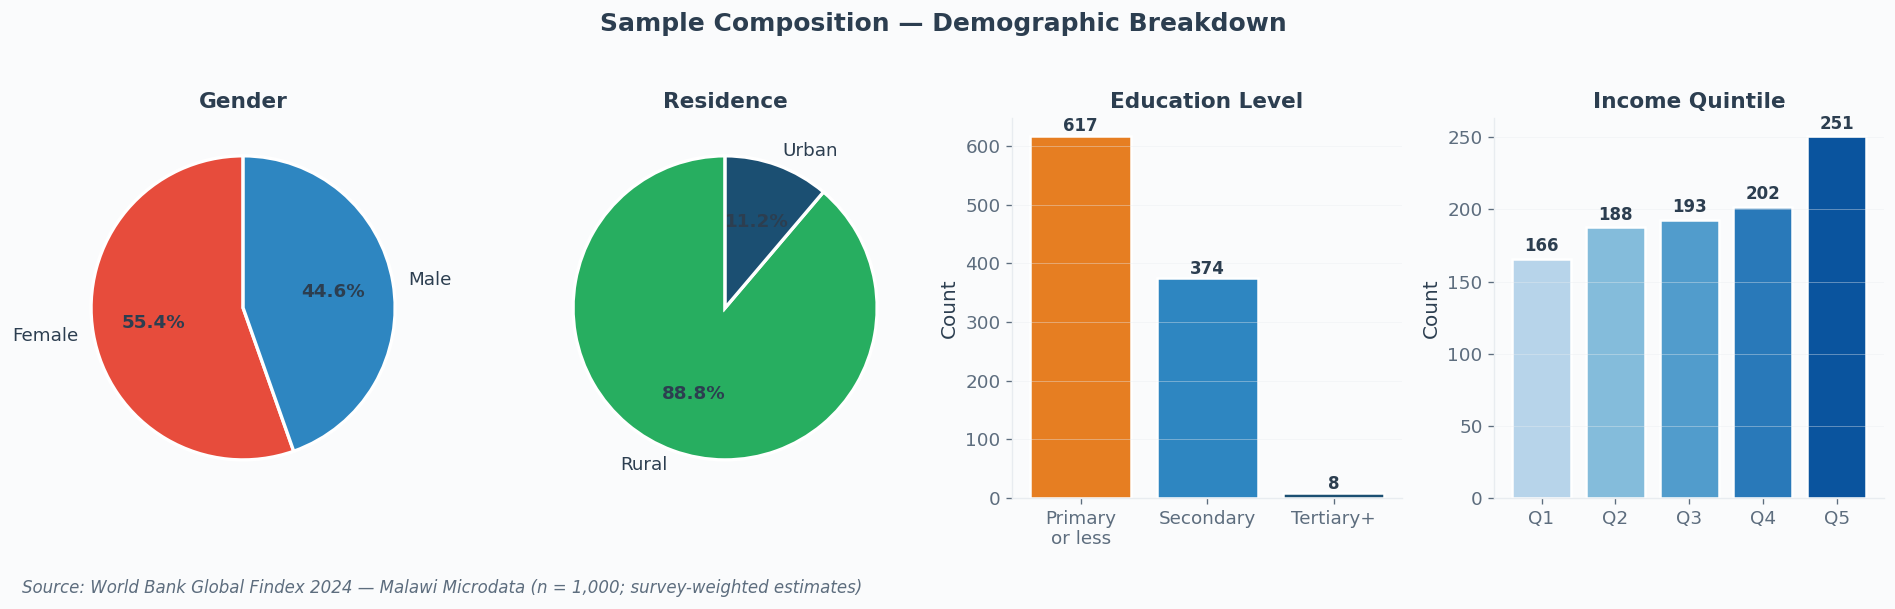

In [9]:
# ─── Demographic Variables — Styled Table + Visualizations ────────────────
demo_data = {
    'Variable': ['female', 'urbanicity', 'educ', 'inc_q'],
    'Label': ['Gender', 'Residence', 'Education', 'Income Quintile'],
    'Coding': ['1=Female, 2=Male', '1=Rural, 2=Urban',
               '1=Primary or less, 2=Secondary, 3=Tertiary+',
               '1=Poorest 20% … 5=Richest 20%'],
    'N Categories': [2, 2, 3, 5],
}
demo_df = pd.DataFrame(demo_data).set_index('Variable')
display(styled_table(demo_df, title="👥 Key Demographic Variables"))

# ─── Demographic Distribution Charts ─────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

# Gender
ax = axes[0]
g_counts = df['female'].value_counts().sort_index()
g_labels = ['Female', 'Male']
g_colors = ['#E74C3C', COLORS['secondary']]
wedges, _, autotexts = ax.pie(g_counts, labels=g_labels, colors=g_colors,
    autopct='%1.1f%%', startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
for t in autotexts: t.set_fontweight('bold')
ax.set_title('Gender', fontweight='bold', fontsize=13)

# Residence
ax = axes[1]
u_counts = df['urbanicity'].value_counts().sort_index()
u_labels = ['Rural', 'Urban']
u_colors = [COLORS['success'], COLORS['primary']]
wedges, _, autotexts = ax.pie(u_counts, labels=u_labels, colors=u_colors,
    autopct='%1.1f%%', startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
for t in autotexts: t.set_fontweight('bold')
ax.set_title('Residence', fontweight='bold', fontsize=13)

# Education
ax = axes[2]
e_counts = df['educ'].value_counts().sort_index()
e_labels = ['Primary\nor less', 'Secondary', 'Tertiary+']
e_colors = [COLORS['accent'], COLORS['secondary'], COLORS['primary']]
bars = ax.bar(e_labels, e_counts, color=e_colors, edgecolor='white', linewidth=1.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{int(bar.get_height())}', ha='center', fontweight='bold', fontsize=10)
ax.set_ylabel('Count')
ax.set_title('Education Level', fontweight='bold', fontsize=13)
ax.grid(axis='y', alpha=0.45)

# Income Quintile
ax = axes[3]
q_counts = df['inc_q'].value_counts().sort_index()
q_labels = [f'Q{i}' for i in range(1, 6)]
gradient = [plt.cm.Blues(0.3 + i*0.14) for i in range(5)]
bars = ax.bar(q_labels, q_counts, color=gradient, edgecolor='white', linewidth=1.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{int(bar.get_height())}', ha='center', fontweight='bold', fontsize=10)
ax.set_ylabel('Count')
ax.set_title('Income Quintile', fontweight='bold', fontsize=13)
ax.grid(axis='y', alpha=0.45)

plt.suptitle('Sample Composition — Demographic Breakdown', fontsize=15, fontweight='bold', y=1.03)
add_source_note(fig)
plt.tight_layout()
plt.savefig('../outputs/figures/demographic_composition.png', dpi=200, bbox_inches='tight')
plt.show()

## Missing Values Analysis

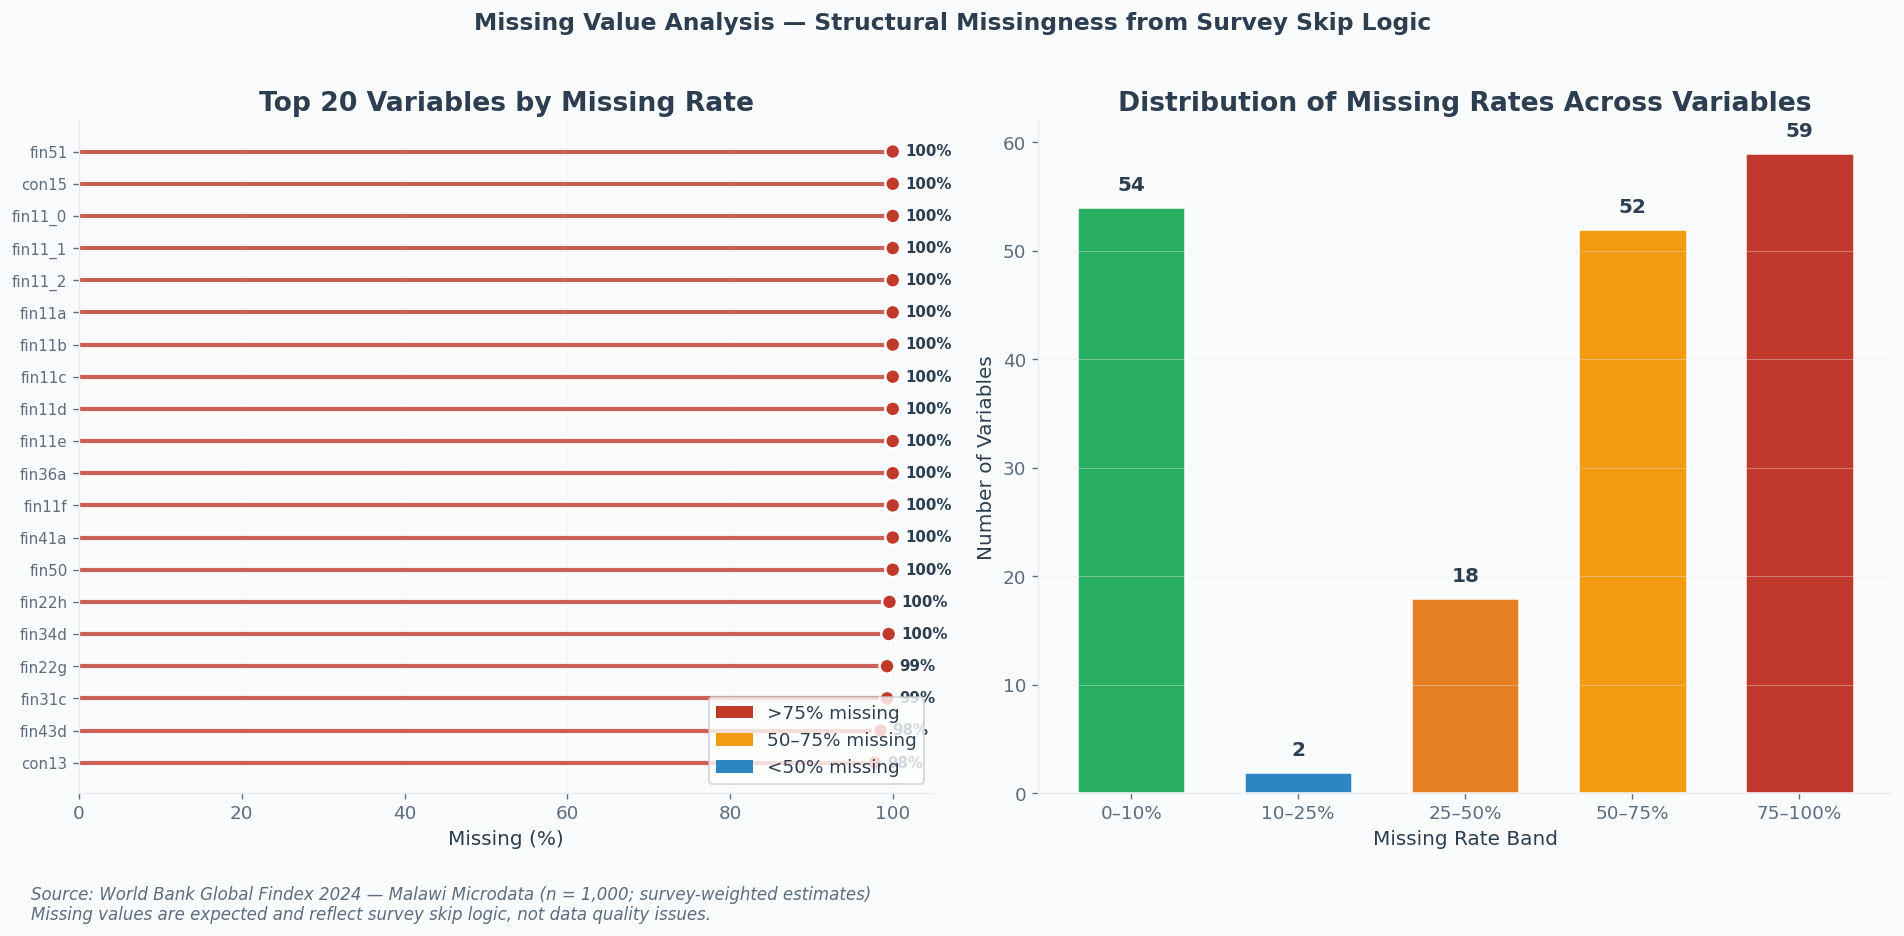

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# MISSING VALUES — Professional Heatmap & Summary
# ═══════════════════════════════════════════════════════════════════════════════

missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

# Summary cards
n_complete = (missing_pct == 0).sum()
n_over50 = (missing_pct > 50).sum()
n_over75 = (missing_pct > 75).sum()

kpi_cards([
    ("0% Missing", f"{n_complete}", "✅", COLORS['success']),
    (">50% Missing", f"{n_over50}", "⚠️", COLORS['warning']),
    (">75% Missing", f"{n_over75}", "🔴", COLORS['danger']),
    ("Median Missing %", f"{missing_pct.median():.0f}%", "📉", COLORS['secondary']),
])

# ─── Top 20 Missing Variables — Lollipop Chart ──────────────────────────
top_missing = missing_pct.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax1 = axes[0]
y_pos = np.arange(len(top_missing))
colors_lollipop = [COLORS['danger'] if v > 75 else COLORS['warning'] if v > 50
                   else COLORS['secondary'] for v in top_missing.values]

ax1.hlines(y_pos, 0, top_missing.values, color=colors_lollipop, linewidth=2.5, alpha=0.8)
ax1.scatter(top_missing.values, y_pos, color=colors_lollipop, s=80, zorder=5, edgecolors='white', linewidth=1.5)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(top_missing.index, fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('Missing (%)')
ax1.set_title('Top 20 Variables by Missing Rate', fontweight='bold')
ax1.set_xlim(0, 105)
ax1.grid(axis='x', alpha=0.45)

for i, v in enumerate(top_missing.values):
    ax1.text(v + 1.5, i, f'{v:.0f}%', va='center', fontsize=9, fontweight='bold', color=COLORS['text'])

# Legend
legend_elements = [
    mpatches.Patch(facecolor=COLORS['danger'], label='>75% missing'),
    mpatches.Patch(facecolor=COLORS['warning'], label='50–75% missing'),
    mpatches.Patch(facecolor=COLORS['secondary'], label='<50% missing'),
]
ax1.legend(handles=legend_elements, loc='lower right', frameon=True, facecolor='white')

# ─── Missing Rate Distribution Histogram ─────────────────────────────────
ax2 = axes[1]
bins_edges = [0, 10, 25, 50, 75, 100]
bin_colors = [COLORS['success'], COLORS['secondary'], COLORS['accent'], COLORS['warning'], COLORS['danger']]
bin_labels = ['0–10%', '10–25%', '25–50%', '50–75%', '75–100%']
bin_counts = [((missing_pct >= lo) & (missing_pct < hi)).sum() for lo, hi in zip(bins_edges[:-1], bins_edges[1:])]

bars = ax2.bar(bin_labels, bin_counts, color=bin_colors, edgecolor='white', linewidth=1.5, width=0.65)
for bar, c in zip(bars, bin_counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{c}', ha='center', fontweight='bold', fontsize=12, color=COLORS['text'])
ax2.set_xlabel('Missing Rate Band')
ax2.set_ylabel('Number of Variables')
ax2.set_title('Distribution of Missing Rates Across Variables', fontweight='bold')
ax2.grid(axis='y', alpha=0.45)

plt.suptitle('Missing Value Analysis — Structural Missingness from Survey Skip Logic',
             fontsize=14, fontweight='bold', y=1.02)
add_source_note(fig, "Missing values are expected and reflect survey skip logic, not data quality issues.")
plt.tight_layout()
plt.savefig('../outputs/figures/missing_values.png', dpi=200, bbox_inches='tight')
plt.show()

**Critical Understanding:**  
Missing values in Global Findex data are **structural and expected**, not data quality problems. They occur because:
- Questions about account usage are only asked to account holders
- Some questions are region-specific (e.g., mobile money questions in Sub-Saharan Africa)
- Follow-up questions depend on previous responses (skip logic)

**I DID NOT:**
- Globally delete rows with missing values
- Impute missing values
- Treat missing as "No" without checking codebook

**I DID:**
- Respect skip logic when analyzing each variable
- Check codebook for eligibility conditions
- Use only valid responses for each indicator

## Codebook Reference

## Create Working Copy

**Data Management Strategy:**
- `df_raw`: Untouched copy of original data
- `df`: Working copy that can be modified in analysis
- All notebooks will reload from the CSV to ensure independence

## Data Validation Summary

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# DATA VALIDATION SUMMARY — Professional Dashboard
# ═══════════════════════════════════════════════════════════════════════════════

summary_items = [
    ('Dataset loaded', f'{df.shape[0]:,} observations, {df.shape[1]:,} variables', True),
    ('No duplicate records', f'{df.duplicated().sum()} found', df.duplicated().sum() == 0),
    ('Single country', df['economy'].iloc[0], df['economy'].nunique() == 1),
    ('Survey weights valid', f'Range [{df["wgt"].min():.2f}, {df["wgt"].max():.2f}]', wgt_ok),
    ('Demographics present', 'female, urbanicity, educ, inc_q', True),
    ('Core FI variables present', 'account, account_mob, account_fin', True),
]

html = f"""
<div style="max-width:750px;margin:auto;background:white;border-radius:14px;padding:24px 28px;
    box-shadow:0 3px 15px rgba(0,0,0,0.08);border-left:5px solid {COLORS['primary']};">
  <h3 style="color:{COLORS['primary']};margin:0 0 16px 0;">✅ Data Validation Summary</h3>
  <table style="width:100%;border-collapse:collapse;">
    <tr style="background:{COLORS['primary']};color:white;">
      <th style="padding:8px 12px;text-align:left;">Check</th>
      <th style="padding:8px 12px;text-align:center;">Status</th>
      <th style="padding:8px 12px;text-align:left;">Detail</th>
    </tr>"""
for label, detail, passed in summary_items:
    icon = '✅' if passed else '❌'
    row_bg = '' if passed else 'background:#FADBD8;'
    html += f"""
    <tr style="{row_bg}border-bottom:1px solid {COLORS['grid']};">
      <td style="padding:8px 12px;font-weight:500;">{label}</td>
      <td style="padding:8px 12px;text-align:center;font-size:18px;">{icon}</td>
      <td style="padding:8px 12px;color:{COLORS['muted']};">{detail}</td>
    </tr>"""
html += """
  </table>
  <div style="margin-top:14px;padding:10px 14px;background:#EBF5FB;border-radius:8px;font-size:12px;">
    <strong>⚠️ Important:</strong> Missing values are <em>structural</em> (survey skip logic), not quality issues.
    Always use survey weights for population estimates. Consult codebook for interpretation.
  </div>
  <div style="margin-top:10px;text-align:center;font-size:13px;font-weight:bold;color:#27AE60;">
    → Data is clean and ready for analysis → Proceed to Notebook 02
  </div>
</div>"""

display(HTML(html))

Check,Status,Detail
Dataset loaded,✅,"1,000 observations, 199 variables"
No duplicate records,✅,0 found
Single country,✅,Malawi
Survey weights valid,✅,"Range [0.25, 2.75]"
Demographics present,✅,"female, urbanicity, educ, inc_q"
Core FI variables present,✅,"account, account_mob, account_fin"


## Next Steps

The next notebook will focus on:
- Calculating weighted national financial inclusion rates
- Disaggregating by gender, residence, income, and education
- Comparing account types (mobile money vs. bank accounts)
- Analyzing saving and borrowing behavior
- Examining digital payment adoption

All analysis will properly apply survey weights and respect variable eligibility conditions.

*End of Notebook 01*